1. **Restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart)
2. **Run all cells** (in the menubar, select Cell$\rightarrow$Run All).
3. __Use the__ `Validate` __button in the Assignments tab before submitting__.

__Include comments, derivations, explanations, graphs, etc.__ 

You __work in groups__ (= 3 people). __Write the full name and S/U-number of all team members!__

---

# Assignment 4 (Statistical Machine Learning 2024)
# **Deadline: 20 December 2024**

## Instructions
* Fill in any place that says `YOUR CODE HERE` or `YOUR ANSWER HERE` __including comments, derivations, explanations, graphs, etc.__ 
Elements and/or intermediate steps required to derive the answer have to be in the report. If an exercise requires coding, explain briefly what the code does (in comments). All figures should have titles (descriptions), axis labels, and legends.
* __Please use LaTeX to write down equations/derivations/other math__! How to do that in Markdown cells can be found [here](https://www.fabriziomusacchio.com/blog/2021-08-10-How_to_use_LaTeX_in_Markdown/), a starting point for various symbols is [here](https://www.overleaf.com/learn/latex/Mathematical_expressions).
* Please do __not add new cells__ to the notebook, try to write the answers only in the provided cells. Before you turn the assignment in, make sure everything runs as expected.
* __Use the variable names given in the exercises__, do not assign your own variable names. 
* __Only one team member needs to upload the solutions__. This can be done under the Assignments tab, where you fetched the assignments, and where you can also validate your submissions. Please do not change the filenames of the individual Jupyter notebooks.

For any problems or questions regarding the assignments, ask during the tutorial or send an email to charlotte.cambiervannooten@ru.nl and janneke.verbeek@ru.nl .

## Introduction
Assignment 4 consists of:
1. Bayesian inference in binary response problem (50 points);
2. The EM algorithm for doping detection (50 points)__;
3. Gibbs sampling and Metropolis-Hastings (50 points);
4. __State-Space models (50 points)__.

## Libraries

Please __avoid installing new packages__, unless really necessary.

In [221]:
import IPython
assert IPython.version_info[0] >= 3, "Your version of IPython is too old, please update it to at least version 3."

import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Set fixed random seed for reproducibility
np.random.seed(2024)

## State-Space models (25 points)
It is nearly Christmas, and a snowstorm is howling across the Arctic. While on his way back from his yearly package delivery route, Santa Claus accidentally broke his Sled Positioning System (SPS). He has massive trouble finding his North Pole base again in this weather, and is now circling the base.

Since the SPS is broken, the elves have lost Santa's exact position - however, they have detected Rudolf on their Reindeer Detection And Ranging (REIDAR) system.

Luckily, the data elves have figured out that the SPS system last emitted a location (latitude and longitude) a few minutes ago, so they might be able to track and guide Santa's sled to safety after all. They enlisted your help to track and predict the trajectory of Santa's sled, based on their REIDAR measurements.

### Part 1 - State-space model
As the elves have some experience working with both the SPS and the REIDAR system, the lead Data Elf has modelled the movement of the sled over time with the following linear Gaussian state-space model:

$$ x_t = Ax_{t-1} + w_t, w_t \sim \mathcal{N}(0, Q),$$
$$ y_t = Cx_{t} + v_t, v_t \sim \mathcal{N}(0, R).$$

* $x_t \in \mathbb{R}^{4 \times 1}$ is the true location and velocity of the sled at time $t$, consisting of $[x, y, \dot x, \dot y]$, as emitted by the SPS. The location consists of an $x$ and $y$ coordinate, as well as a velocity in the $x$ direction, $\dot x$, and a velocity in the $y$ direction, $\dot y$.  
* $y_t \in \mathbb{R}^{2 \times 1}$ is the location $[x, y]$ received by the elves at time $t$, as detected by the REIDAR.
* $A \in \mathbb{R}^{4 \times 4}$ is the state transition matrix. Initialize this matrix as $0.25\mathbf{I} + \mathcal{N}(\mathbf{0}, 0.01 \cdot \mathbf{I})$.
* $C \in \mathbb{R}^{2 \times 4}$ is the state-to-measurement matrix. Initialize this matrix randomly from an uniform distribution.
* $Q \in \mathbb{R}^{4 \times 4}$ is the process noise of the sled's movement (reindeers are somewhat unstable). 
* $R \in \mathbb{R}^{2 \times 2}$ is the observation noise of the sled's movement (the REIDAR is not exactly accurate, and has a measurement error of $0.1*\mathbf{I}$.).

The last true location (in meters) and velocity (in meters per second) that was emitted by the sled is $$x_0 = [x, y, \dot x, \dot y] =  [0, 0, 0.1, 0.1].$$

Besides the location, the SPS also gives a matrix of state covariances, $P_0$, representing how certain the SPS is about the location and velocity of the sled:

 $$ \begin{bmatrix}
0.1 & 0.1 & 0 & 0 \\
0.1 & 0.1 & 0 & 0 \\
0 & 0 & 10 & 0 \\
0 & 0 & 0 & 10
\end{bmatrix} = \begin{bmatrix}
\sigma_x^2& \sigma_{xy} & \sigma_{x\dot x}& \sigma_{x\dot y}\\
\sigma_{xy} & \sigma_{y^2} & \sigma_{y \dot x}& \sigma_{y\dot y} \\
\sigma_{x\dot x} & \sigma_{y\dot x} & \sigma_{\dot x^2} & \sigma_{\dot x \dot y} \\
\sigma_{x\dot y} & \sigma_{y\dot y} & \sigma_{\dot x \dot y} & \sigma_{\dot y^2}
\end{bmatrix} $$

As you are a curious data science student, your first want to implement your own version of the linear-Gaussian model, so that you understand how it works. 

1. Implement the linear Gaussian state-space model. 

In [222]:
# I don't know if this should be 0.01 as defined in the problem or 0.1 as given here?
# A = 0.25 * np.eye(4) + np.random.uniform(0, 0.01, (4, 4))
A = 0.25 * np.eye(4) + np.random.uniform(0, 0.1, (4, 4))
C = np.random.uniform(size=(2, 4))
Q = np.ones((4, 4))/0.2
R = np.eye(2) * 0.1
N = 100


In [223]:
def ssm(xt, A, C, Q, R, N, dim_x, dim_y):
    """
    State-Space model (linear gaussian)

    Parameters
    ----------
    xt : 
    A :
    C :
    Q : 
    R :
    N :
    dim_x :
    dim_y :

    Returns xs, ys
    -------
    """

    # adding initial conditions into xs and ys
    xs = np.zeros((N+1, dim_x))
    ys = np.zeros((N+1, dim_y))
    # I assume that if we know initial true location then the same is observed, thus x=y=x0
    xs[0] = xt
    ys[0] = xt[0:1]
    for i in range(1, N+1):
        # getting noise components
        wt = np.random.multivariate_normal(np.zeros(shape=dim_x), Q)
        vt = np.random.multivariate_normal(np.zeros(shape=dim_y), R)
        
        xs[i] = A@xs[i-1] + wt
        ys[i] = C@xs[i] + vt
    return xs, ys

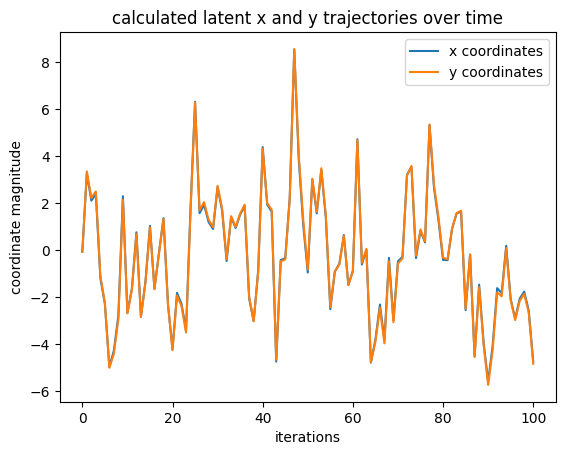

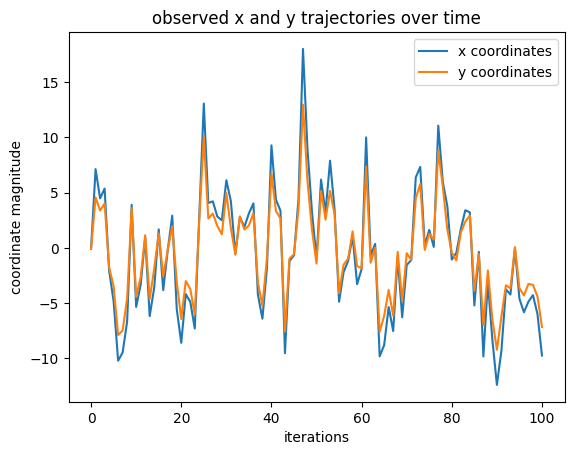

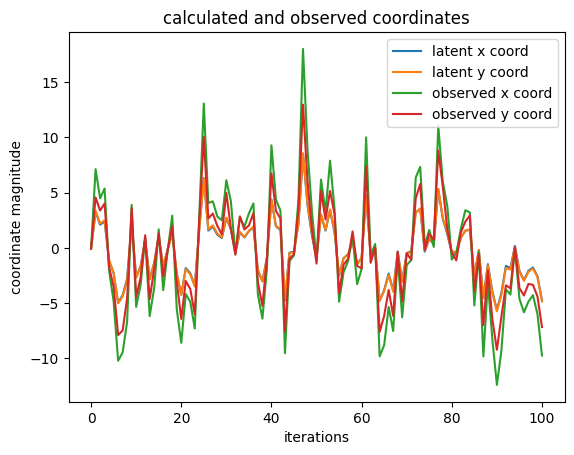

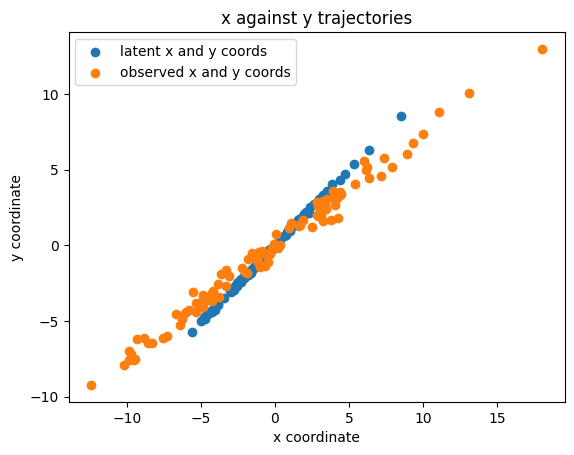

In [224]:
# initializations
P0 = np.array([[0.1, 0.1, 0, 0], [0.1, 0.1, 0, 0], [0, 0, 10, 0], [0, 0, 0, 10]])
x0 = np.array([0, 0, 0.1, 0.1])

u = np.random.multivariate_normal(np.zeros(shape=x0.shape), P0)
xt = x0 + u
xs, ys = ssm(xt, A, C, Q, R, N, 4, 2)
# It's unclear whether you consider xs and ys the coordinates or latent and observed variables, so I've decided to plot all of them
# coordinates x - true location
plt.plot(xs[:, 0], label='x coordinates')
plt.plot(xs[:, 1], label='y coordinates')
plt.legend()
plt.title('calculated latent x and y trajectories over time')
plt.xlabel('iterations')
plt.ylabel('coordinate magnitude')
plt.show()


# observed location
plt.plot(ys[:, 0], label='x coordinates')
plt.plot(ys[:, 1], label='y coordinates')
plt.legend()
plt.xlabel('iterations')
plt.ylabel('coordinate magnitude')
plt.title('observed x and y trajectories over time')
plt.show()

# plt x against y
plt.plot(xs[:, 0], label='latent x coord')
plt.plot(xs[:, 1], label='latent y coord')
plt.plot(ys[:, 0], label='observed x coord')
plt.plot(ys[:, 1], label='observed y coord')
plt.legend()
plt.xlabel('iterations')
plt.ylabel('coordinate magnitude')
plt.title('calculated and observed coordinates')
plt.show()


# plt x against y
plt.scatter(xs[:, 0], xs[:, 1], label='latent x and y coords')
plt.scatter(ys[:, 0], ys[:, 1], label='observed x and y coords')
plt.title('x against y trajectories')
plt.xlabel('x coordinate')
plt.ylabel('y coordinate')
plt.legend()
plt.show()


## Part 2 - Kalman filter
As you have just had a lecture on sequential methods you decide to implement a Kalman filter (after all, one of the applications of a Kalman filter is aircraft tracking). 

Assume you do not have access to the true locations $x_t$.


1. Implement the `predict` step of the Kalman filter. The function should take $A$ and $x_{t}$, and return a predicted state $x_{t+1|t}$, as well as its covariance, $P_{t+1|t}$. 

In [225]:
P_init = np.array([ [10, 5, 0,  0],\
                [5, 10,  0,  0],\
                [0,   0,   10,  0], \
                [0,   0,    0, 10]])

In [226]:
def predict(A, Q, xt, Pt):
    """
    Predict step (kalman)

    Parameters
    ----------
    A :
    Q : 
    xt :
    Pt :

    Returns xp, Pp
    -------
    """

    xp = A@xt
    Pp = A@Pt@A.T + Q
    return xp, Pp

2. Implement the `update` step of the Kalman filter. The function should take $C, R, x, y$ and return the Kalman gain $K_t$, the updated state $\hat x_{t|t}$

In [227]:
def update(C, R, xp, yt, Pp):
    """
    Update step (kalman)

    Parameters
    ----------
    C :
    R : 
    xp :
    yt :
    Pp :

    Returns Kt, xtt, Ptt
    -------
    """
 
    Kt = Pp@C.T @ np.linalg.inv(C@Pp@C.T + R)
    xtt = xp + Kt@ (yt - C @xp)
    Ptt = (np.eye(4) - Kt@C)@Pp
    
    return Kt, xtt, Ptt

3. Implement a Kalman smoother (Hint: implement a function that makes one smoothing step, and a function that runs the smoother over all data points). 

In [228]:
def smoother_update(xhat, x_pred, Phat, P_pred, x_smooth_next, P_smooth_next):
    J = Phat@A.T @ np.linalg.inv(P_pred)
    x_smooth = xhat + J @ (x_smooth_next - x_pred)
    P_smooth = Phat + J @ (P_smooth_next - P_pred) @ J.T
    return x_smooth, P_smooth
    

In [229]:
def kalman_smoother(xfilt, x_pred, Pfilt, P_pred):
    xs_smooth = np.zeros(x_pred.shape)
    Ps_smooth = np.zeros(P_pred.shape)
    
    xs_smooth[-1] = xfilt[-1]
    Ps_smooth[-1] = Pfilt[-1]
    # iteration backwards in time
    for t in range(N-2, -1, -1):
        xs_smooth[t], Ps_smooth[t] = smoother_update(xfilt[t], x_pred[t+1], Pfilt[t], P_pred[t+1], xs_smooth[t+1], Ps_smooth[t+1])
    return xs_smooth, Ps_smooth
        

4. Predict the position and velocity of the sled for 100 time steps. Your initial guess vector for the position/velocity vector is $[0.5, 0.5, 2, 2]$. Plot the actual, observed and filtered for all.

In [230]:
xt = np.array([0.5, 0.5, 2, 2])

def kalman_filter(xt, Pt, ys, A, C, R, Q, N):
    """
    Update step (kalman)

    Parameters
    ----------
    xt : 
    Pt : 
    ys : 
    A : 
    C : 
    R : 
    Q : 
    N : 

    Returns xfilt, Pfilt, x_preds, P_preds
    -------
    """
    xfilt = np.zeros((N, 4))
    x_preds = np.zeros((N, 4))
    Pfilt = np.zeros((N, 4, 4))
    P_preds = np.zeros((N, 4, 4))
    xfilt[0] = xt
    Pfilt[0] = Pt

    for i in range(1, N):
        x_preds[i], P_preds[i] = predict(A, Q, xfilt[i-1], Pfilt[i-1])
        _, xfilt[i], Pfilt[i] = update(C, R, x_preds[i], ys[i-1], P_preds[i]) 

    return xfilt, Pfilt, x_preds, P_preds        

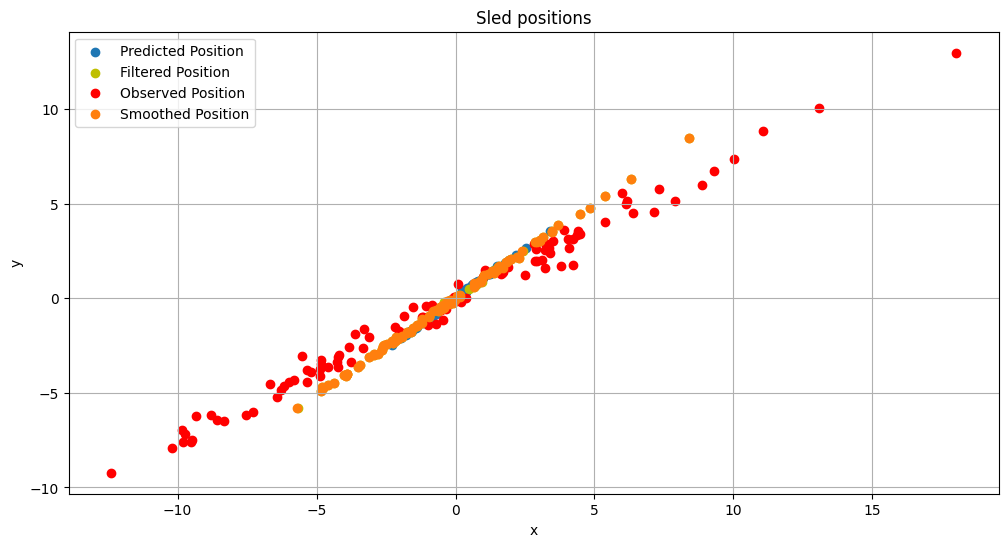

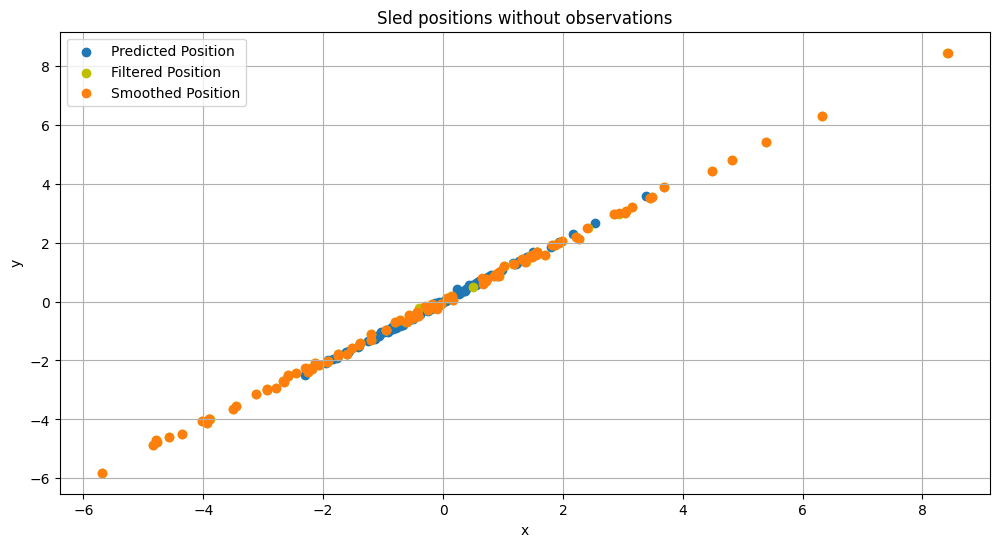

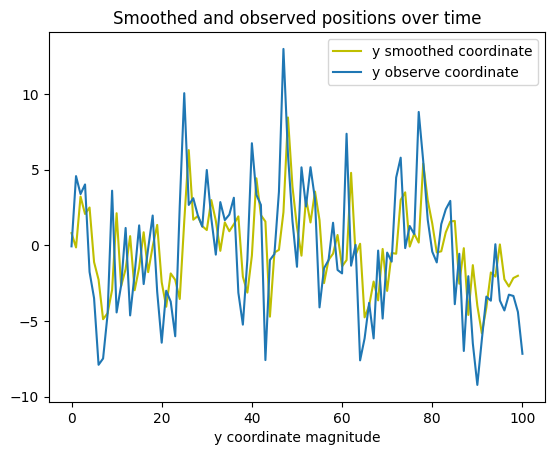

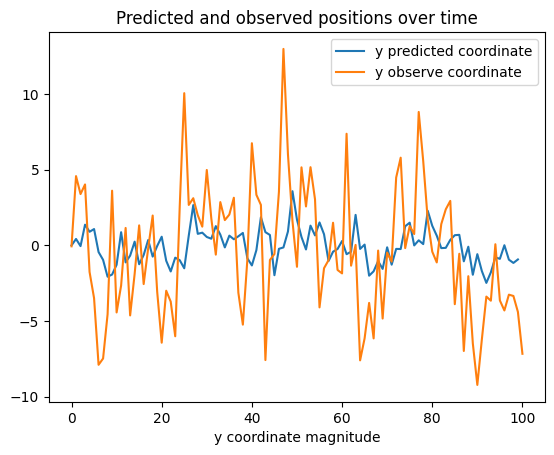

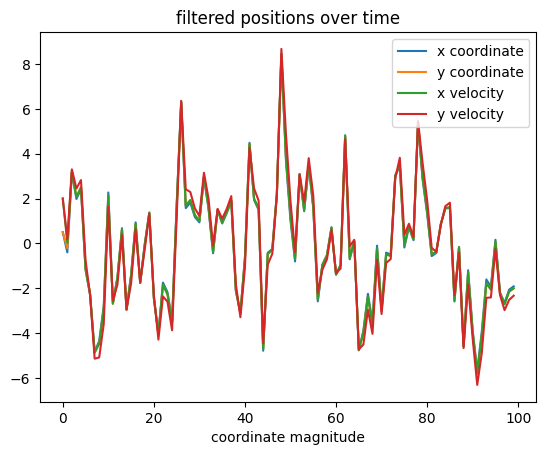

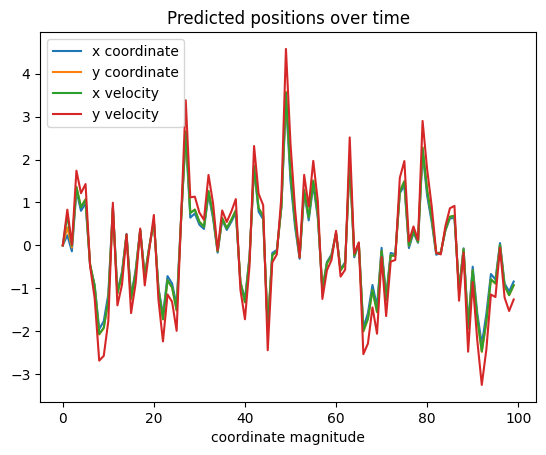

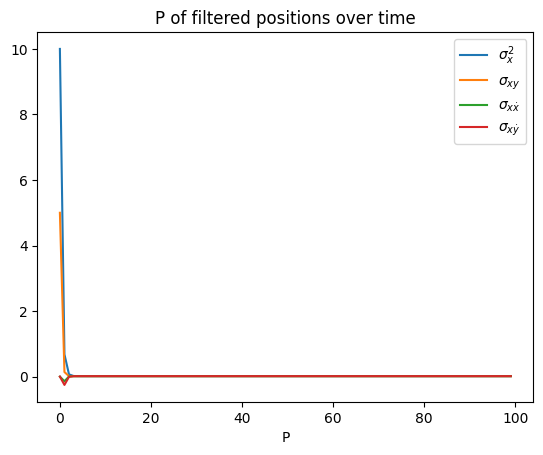

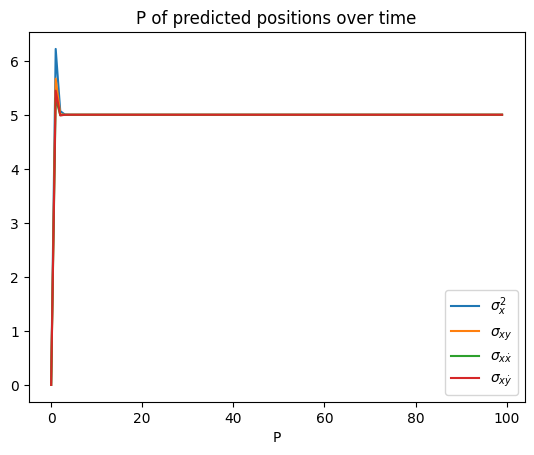

In [231]:
"""
Using the kalman filter, produce the four plots
"""
xt = np.array([0.5, 0.5, 2, 2])
P_init = np.array([ [10, 5, 0,  0],\
                [5, 10,  0,  0],\
                [0,   0,   10,  0], \
                [0,   0,    0, 10]])

xfilt, Pfilt, x_preds, P_preds = kalman_filter(xt, P_init, ys, A, C, R, Q, 100)
# I assume that in order to compare Kalman filter with Kalman smoother I should call these two functions separately 
xsmooth, Psmooth = kalman_smoother(xfilt, x_preds, Pfilt, P_preds)

# plotting
plt.figure(figsize=(12, 6))
plt.scatter(x_preds[:, 0], x_preds[:, 1], label="Predicted Position")
plt.scatter(xfilt[:, 0], xfilt[:, 1], label="Filtered Position", color='y')
plt.scatter(ys[:, 0], ys[:, 1], label='Observed Position', color='r')
plt.scatter(xsmooth[:, 0], xsmooth[:, 1], label="Smoothed Position")
plt.title("Sled positions")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(x_preds[:, 0], x_preds[:, 1], label="Predicted Position")
plt.scatter(xfilt[:, 0], xfilt[:, 1], label="Filtered Position", color='y')
plt.scatter(xsmooth[:, 0], xsmooth[:, 1], label="Smoothed Position")
plt.title("Sled positions without observations")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()
plt.show()


plt.plot(xsmooth[:, 1], label='y smoothed coordinate', color='y')
plt.plot(ys[:, 1], label='y observe coordinate')
plt.xlabel('iterations')
plt.xlabel('y coordinate magnitude')
plt.title('Smoothed and observed positions over time')
plt.legend()
plt.show()

plt.plot(x_preds[:, 1], label='y predicted coordinate')
plt.plot(ys[:, 1], label='y observe coordinate')
plt.xlabel('iterations')
plt.xlabel('y coordinate magnitude')
plt.title('Predicted and observed positions over time')
plt.legend()
plt.show()

plt.plot(xfilt[:, 0], label='x coordinate')
plt.plot(xfilt[:, 1], label='y coordinate')
plt.plot(xfilt[:, 2], label='x velocity')
plt.plot(xfilt[:, 3], label='y velocity')
plt.xlabel('iterations')
plt.xlabel('coordinate magnitude')
plt.title('filtered positions over time')
plt.legend()
plt.show()

plt.plot(x_preds[:, 0], label='x coordinate')
plt.plot(x_preds[:, 1], label='y coordinate')
plt.plot(x_preds[:, 2], label='x velocity')
plt.plot(x_preds[:, 3], label='y velocity')
plt.xlabel('iterations')
plt.xlabel('coordinate magnitude')
plt.title('Predicted positions over time')
plt.legend()
plt.show()

plt.plot(Pfilt[:, 0, 0], label='$\sigma_x^2$')
plt.plot(Pfilt[:, 0, 1], label='$\sigma_{xy}$')
plt.plot(Pfilt[:, 0, 2], label='$ \sigma_{x\dot x}$')
plt.plot(Pfilt[:, 0, 3], label='$\sigma_{x\dot y}$')
plt.xlabel('iterations')
plt.xlabel('P')
plt.title('P of filtered positions over time')
plt.legend()
plt.show()

plt.plot(P_preds[:, 0, 0], label='$\sigma_x^2$')
plt.plot(P_preds[:, 0, 1], label='$\sigma_{xy}$')
plt.plot(P_preds[:, 0, 2], label='$ \sigma_{x\dot x}$')
plt.plot(P_preds[:, 0, 3], label='$\sigma_{x\dot y}$')
plt.xlabel('iterations')
plt.xlabel('P')
plt.title('P of predicted positions over time')
plt.legend()
plt.show()

5. Reflect on your results. Assuming you do not have the true trajectory of the sled, but you do have the observations $y$, how well does the Kalman filter predict the true sled trajectory? 

It seems that Kalman filter and smoothing calculations are correct, but there's either mistake in definition or the noise is a bit too big to get predictions that are more accurate because the maximum values of observations seems potentially too high, compared with prediction values.

6. Compare the results of smoothing to the Kalman filter predictions. What does the smoother do?

Once Kalman filter gets all of the predictions, Kalman smoother 'smooths' those predictions by bringing them somewhat closer to observations.